# Desmatamento PRODES em escala municipal

### Do limite territorial oficial ao mapa, ao gráfico e à auditoria do dado — inteiramente por API

**AmbGEO** · Python · IBGE + INPE/TerraBrasilis

---

## O que este notebook faz

Responde a duas perguntas sobre qualquer município brasileiro — **quanto foi desmatado** e
**em que anos** — construindo a resposta do zero a partir das fontes oficiais, sem nenhum
download manual de arquivo.

O fluxo tem dez etapas encadeadas:

| | Etapa | Resultado |
|---|---|---|
| 1 | Identificação do município | código IBGE |
| 2 | Limite territorial | polígono oficial vigente |
| 3 | Biomas de abrangência | quais camadas do PRODES consultar |
| 4 | Mapa de localização | contexto geográfico da análise |
| 5 | Extração do PRODES | polígonos de desmatamento da região |
| 6 | Validação geométrica e recorte | dado limpo, restrito ao município |
| 7 | Mapa por ano | distribuição espacial do desmatamento |
| 8 | Evolução anual | tendência ao longo do período |
| 9 | Exportação | GeoPackage e CSV reutilizáveis |
| 10 | Auditoria de sobreposição | verificação da consistência do dado |

## Por que fazer assim

O caminho convencional para essa análise envolve baixar o conjunto nacional do PRODES,
baixar a malha municipal, abrir os dois num SIG, recortar, calcular áreas e exportar tabelas.
São vários gigabytes e um roteiro manual que precisa ser repetido a cada município e a cada
atualização da base.

Consultando as APIs, o recorte espacial é resolvido **no servidor**: chegam apenas os polígonos
que interessam, na versão vigente da base.

| Abordagem manual | Consulta por API |
|---|---|
| Conjunto nacional completo para analisar um município | Filtro espacial no servidor: apenas o recorte |
| Arquivo local que envelhece | Dado vigente a cada execução |
| Etapas manuais difíceis de documentar | O código é a documentação do método |
| Novo município significa refazer tudo | Novo município significa trocar um parâmetro |

Há ainda uma característica do PRODES que orienta o desenho deste fluxo: **a base é organizada
por bioma**, não por unidade da federação. Amazônia, Cerrado, Caatinga, Pantanal, Pampa e Mata
Atlântica têm cada um a sua própria camada, já recortada no limite do bioma correspondente.
Municípios situados em faixas de transição pertencem a mais de um bioma e, portanto, aparecem
repartidos entre duas camadas.

Por isso a etapa 3 determina os biomas de abrangência a partir da cartografia oficial do IBGE,
e as etapas seguintes consultam todas as camadas necessárias.

> **Fontes de dados**
> · IBGE — [API de Localidades](https://servicodados.ibge.gov.br/api/docs/localidades) e [API de Malhas Territoriais v3](https://servicodados.ibge.gov.br/api/docs/malhas?versao=3)
> · IBGE — Biomas do Brasil, via WFS do [Geoserviços](https://geoservicos.ibge.gov.br/geoserver/ows)
> · INPE — PRODES, via WFS do [TerraBrasilis](https://terrabrasilis.dpi.inpe.br/geoserver/ows)
>
> Todas as fontes são públicas e não exigem cadastro ou chave de acesso.

## 0. Ambiente e dependências

O notebook usa `requests` para as consultas, `pandas` e `geopandas` para manipular os dados e
`matplotlib` para as figuras. Na primeira execução, descomente a linha de instalação.

In [1]:
# !pip install requests pandas geopandas matplotlib

import re
import xml.etree.ElementTree as ET

import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

IBGE = "https://servicodados.ibge.gov.br"
IBGE_GEO = "https://geoservicos.ibge.gov.br/geoserver/ows"
TERRABRASILIS = "https://terrabrasilis.dpi.inpe.br/geoserver"


# Formata número no padrão brasileiro: 1.234,5 (ponto no milhar, vírgula no decimal)
def br(x, casas=1):
    return f"{x:,.{casas}f}".replace(",", "§").replace(".", ",").replace("§", ".")


print("geopandas", gpd.__version__)

geopandas 1.1.3


## 1. Parâmetros da análise

Esta é a única célula que precisa ser editada de uma análise para outra: o município, a unidade
da federação e o recorte temporal. Os biomas de abrangência são determinados automaticamente na
etapa 3, mas podem ser informados manualmente em `BIOMAS` quando se deseja restringir a análise.

O dicionário `WORKSPACES` relaciona cada bioma ao conjunto de dados correspondente no servidor
do TerraBrasilis, e `NOME_BIOMA_IBGE` faz a correspondência com a nomenclatura usada pelo IBGE.

In [2]:
# ================= CONFIGURAÇÃO =================
MUNICIPIO = "Altamira"      # nome do município
UF        = "PA"            # sigla do estado

BIOMAS = None               # None = cruza o município com a camada de biomas do IBGE
                            # ou force uma lista, ex.: ["amazonia", "cerrado"]

CAMADA_BIOMAS = "CGMAT:qg_2025_240_bioma"   # Biomas 2025, 1:250.000 — WFS do IBGE

ANO_INICIO = 2020           # primeiro ano do recorte temporal
ANO_FIM    = None           # None = até o ano mais recente disponível

CAMADAS_MANUAIS = None      # força a camada de um bioma, ex.:
                            # {"amazonia": "prodes-amazon-nb:yearly_deforestation_biome"}
SAIDA = "prodes_municipio"  # prefixo dos arquivos de saída
# ================================================


# Como o IBGE nomeia cada bioma -> a chave que usamos aqui
NOME_BIOMA_IBGE = {
    "amazonia": "amazonia", "caatinga": "caatinga", "cerrado": "cerrado",
    "mata atlantica": "mata_atlantica", "pampa": "pampa", "pantanal": "pantanal",
}

# Cada bioma do PRODES vive em um "workspace" próprio do GeoServer do TerraBrasilis
WORKSPACES = {
    "amazonia":       "prodes-amazon-nb",
    "cerrado":        "prodes-cerrado-nb",
    "caatinga":       "prodes-caatinga-nb",
    "pantanal":       "prodes-pantanal-nb",
    "pampa":          "prodes-pampa-nb",
    "mata_atlantica": "prodes-mata-atlantica-nb",
}
print(f"Município: {MUNICIPIO} ({UF})")
print(f"Biomas...: {'cruzamento com a camada do IBGE' if BIOMAS is None else ', '.join(BIOMAS)}")
print(f"Período..: {ANO_INICIO} até {'hoje' if ANO_FIM is None else ANO_FIM}")

Município: Altamira (PA)
Biomas...: cruzamento com a camada do IBGE
Período..: 2020 até hoje


## 2. Identificação do município

A **API de Localidades** do IBGE é o cadastro oficial das divisões territoriais do país.
A consulta retorna todos os municípios da unidade da federação informada, e a busca por nome
é feita ignorando acentuação e caixa, de modo que grafias como *Querencia* ou *QUERÊNCIA*
também são aceitas.

O resultado desta etapa é o **código IBGE** do município — sete dígitos que identificam o
território de forma inequívoca e são a chave para todas as consultas seguintes. Altamira, por
exemplo, é o código `1500602`.

Quando o nome não é encontrado, a célula interrompe a execução e sugere os municípios de grafia
semelhante na mesma UF.

In [3]:
def ibge(path, **params):
    """Chama a API do IBGE e devolve o JSON já convertido em objeto Python."""
    r = requests.get(f"{IBGE}{path}", params=params, timeout=180)
    r.raise_for_status()
    return r.json()


def normaliza(texto):
    """Compara nomes ignorando acentos, maiúsculas e espaços extras."""
    import unicodedata
    t = unicodedata.normalize("NFKD", str(texto))
    t = "".join(ch for ch in t if not unicodedata.combining(ch))
    return t.strip().lower()


municipios = pd.DataFrame(ibge(f"/api/v1/localidades/estados/{UF}/municipios"))[["id", "nome"]]
alvo = municipios[municipios["nome"].map(normaliza) == normaliza(MUNICIPIO)]

if alvo.empty:
    parecidos = municipios[municipios["nome"].map(normaliza).str.contains(normaliza(MUNICIPIO))]
    raise ValueError(f"Município '{MUNICIPIO}' não encontrado em {UF}. "
                     f"Parecidos: {parecidos['nome'].tolist()[:10]}")

COD_MUN = str(alvo.iloc[0]["id"])
NOME_MUN = alvo.iloc[0]["nome"]
print(f"{NOME_MUN}/{UF}  ->  código IBGE {COD_MUN}")

Altamira/PA  ->  código IBGE 1500602


## 3. Limite territorial oficial

A [API de Malhas Territoriais](https://servicodados.ibge.gov.br/api/docs/malhas?versao=3)
fornece a geometria do território diretamente em **GeoJSON**, pronta para ser convertida em
`GeoDataFrame`. A rota usa o código obtido na etapa anterior:

```
/api/v3/malhas/municipios/{código}?formato=application/vnd.geo+json
```

As malhas do IBGE são publicadas em **SIRGAS 2000 (EPSG:4674)**, sistema de referência
geodésico oficial do Brasil.

Desta etapa saem três elementos usados adiante:

- **`municipio`** — o polígono do território, em coordenadas geográficas;
- **`CRS_METRICO`** — a zona UTM adequada à posição do município, estimada automaticamente.
  Coordenadas geográficas são medidas angulares; cálculos de área exigem um sistema projetado
  em metros, e a zona UTM local é a escolha apropriada nessa escala;
- **`BBOX`** — a caixa envolvente do território, usada para filtrar as consultas seguintes.

Área do município ....: 159.840 km²
CRS métrico escolhido : WGS 84 / UTM zone 22S
Caixa envolvente .....: (np.float64(-55.6239), np.float64(-9.6452), np.float64(-51.6475), np.float64(-2.9887))


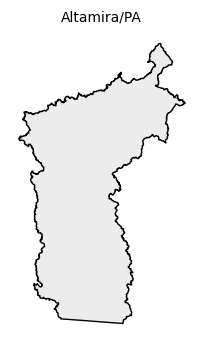

In [4]:
resp = requests.get(
    f"{IBGE}/api/v3/malhas/municipios/{COD_MUN}",
    params={"formato": "application/vnd.geo+json"},
    timeout=180,
)
resp.raise_for_status()

municipio = gpd.GeoDataFrame.from_features(resp.json()["features"], crs="EPSG:4674")
municipio["nome"] = NOME_MUN

# CRS métrico adequado à região do município (UTM), para recorte e cálculo de área
CRS_METRICO = municipio.estimate_utm_crs()
municipio_m = municipio.to_crs(CRS_METRICO)

AREA_MUN_KM2 = float(municipio_m.area.sum() / 1e6)
BBOX = tuple(municipio.total_bounds)   # (minx, miny, maxx, maxy) em graus

print(f"Área do município ....: {br(AREA_MUN_KM2, 0)} km²")
print(f"CRS métrico escolhido : {CRS_METRICO.name}")
print(f"Caixa envolvente .....: {BBOX}")

municipio.plot(facecolor="#ececec", edgecolor="black", linewidth=1, figsize=(4, 4))
plt.axis("off"); plt.title(f"{NOME_MUN}/{UF}", fontsize=10); plt.show()

## 4. Biomas de abrangência

As camadas do PRODES são publicadas separadamente por bioma, já recortadas no limite de cada um.
Um município situado em faixa de transição — como ocorre no norte de Mato Grosso, no Tocantins,
no oeste do Maranhão e no sul do Pará — está distribuído entre duas camadas, e considerar apenas
uma delas produz um resultado incompleto.

Esta etapa determina os biomas de abrangência cruzando o limite municipal com a camada oficial
de biomas do IBGE:

```
CGMAT:qg_2025_240_bioma    (Biomas do Brasil, 1:250.000, WFS do IBGE)
```

A camada contém seis feições, uma por bioma, com os campos `cd_bioma` (1 a 6) e `nm_bioma`.

### Como a consulta é montada

O cruzamento é executado **no servidor**. A geometria do município é enviada num filtro
`INTERSECTS` e a resposta é limitada aos atributos, com `propertyName=cd_bioma,nm_bioma` —
voltam apenas os nomes dos biomas, sem nenhuma geometria. A camada de biomas em 1:250.000 é
volumosa, e nada dela precisa ser transferido.

Três aspectos da montagem da requisição merecem registro:

| Aspecto | Motivo |
|---|---|
| O WKT leva o prefixo **`SRID=4674;`** | declara explicitamente o sistema de referência e fixa a ordem longitude/latitude das coordenadas |
| A requisição usa **POST** | o contorno municipal pode ultrapassar 100 KB em WKT, além do comprimento admitido numa URL |
| O filtro é **`INTERSECTS`**, não `BBOX` | `BBOX` compara envelopes, e o envelope de um bioma continental abrange áreas onde ele não ocorre; `INTERSECTS` compara a geometria real |

### Localização das camadas do PRODES

Definidos os biomas, o notebook consulta o `GetCapabilities` de cada conjunto no TerraBrasilis
para obter o nome da camada de desmatamento anual publicada, e confirma com uma requisição
`resultType=hits` — que retorna apenas a contagem de feições, sem transferir dados — que há
registros na área de interesse.

Caso o serviço de biomas do IBGE esteja indisponível, o notebook consulta os seis conjuntos do
PRODES e utiliza aqueles que retornarem feições, registrando que essa via é menos precisa por
basear-se na caixa envolvente.

### Exemplos de referência

Resultado do cruzamento para municípios de perfis distintos:

| Município | Biomas |
|---|---|
| Altamira (PA) | Amazônia |
| Querência (MT) | Amazônia + Cerrado |
| Barreiras (BA) | Caatinga + Cerrado |
| Corumbá (MS) | Cerrado + Pantanal |
| São Paulo (SP) | Mata Atlântica |
| Bagé (RS) | Pampa |

In [5]:
def biomas_do_municipio(geometria):
    """Pergunta ao WFS do IBGE quais biomas a geometria do município intersecta.

    Vai por POST porque o WKT do contorno é grande, e pede só os atributos:
    nenhuma geometria de bioma trafega.
    """
    corpo = {
        "service": "WFS", "version": "2.0.0", "request": "GetFeature",
        "typeNames": CAMADA_BIOMAS, "outputFormat": "application/json",
        "propertyName": "cd_bioma,nm_bioma",
        # SRID=4674; força a ordem lon/lat — sem ele o servidor lê lat/lon
        "cql_filter": f"INTERSECTS(geom, SRID=4674;{geometria.wkt})",
    }
    r = requests.post(IBGE_GEO, data=corpo, timeout=300)
    r.raise_for_status()
    return [f["properties"]["nm_bioma"] for f in r.json()["features"]]


def listar_camadas(workspace):
    """Lê o GetCapabilities do workspace e devolve os nomes das camadas publicadas."""
    r = requests.get(f"{TERRABRASILIS}/{workspace}/ows",
                     params={"service": "WFS", "version": "2.0.0", "request": "GetCapabilities"},
                     timeout=180)
    r.raise_for_status()
    raiz = ET.fromstring(r.content)
    return [n.text for n in raiz.iter() if n.tag.endswith("}Name") and n.text and ":" in n.text]


def camada_do_bioma(bioma):
    """Nome da camada de desmatamento anual publicada no workspace daquele bioma."""
    if CAMADAS_MANUAIS and bioma in CAMADAS_MANUAIS:
        return CAMADAS_MANUAIS[bioma]
    camadas = listar_camadas(WORKSPACES[bioma])
    candidatas = [n for n in camadas if "yearly_deforestation" in n.lower()] \
              or [n for n in camadas if "deforestation" in n.lower()]
    return candidatas[0] if candidatas else None


def filtros_cql(bbox, ano_inicio, ano_fim=None):
    """Variações de cql_filter, da mais específica à mais tolerante.

    Os biomas têm esquemas ligeiramente diferentes: o campo de geometria pode se chamar
    `geom`, `the_geom` ou `shape`, e nem todos têm a coluna `year`.
    """
    minx, miny, maxx, maxy = bbox
    ano = f" AND year >= {ano_inicio}" + (f" AND year <= {ano_fim}" if ano_fim else "")
    for campo in ("geom", "the_geom", "shape"):
        espacial = f"BBOX({campo},{minx},{miny},{maxx},{maxy},'EPSG:4674')"
        yield espacial + ano      # filtro de ano resolvido no servidor
        yield espacial            # só espacial; o ano filtramos depois, aqui


def sondar(camada, bbox, ano_inicio, ano_fim=None):
    """Quantas feições caem na caixa? `resultType=hits` devolve o número, sem geometria."""
    workspace = camada.split(":")[0]
    for cql in filtros_cql(bbox, ano_inicio, ano_fim):
        try:
            r = requests.get(f"{TERRABRASILIS}/{workspace}/ows",
                             params={"service": "WFS", "version": "2.0.0",
                                     "request": "GetFeature", "typeNames": camada,
                                     "resultType": "hits", "cql_filter": cql},
                             timeout=180)
        except Exception:
            continue
        if r.status_code != 200 or b"ExceptionReport" in r.content[:2000]:
            continue
        achou = re.search(rb'numberMatched="(\d+)"', r.content)
        if achou:
            return int(achou.group(1)), cql      # devolve também o filtro que funcionou
    return None, None


def localizar_prodes(candidatos, bbox, ano_inicio, ano_fim=None):
    """Para cada bioma, acha a camada PRODES e confirma que ela tem feição na caixa."""
    presentes = {}
    for bioma in candidatos:
        try:
            camada = camada_do_bioma(bioma)
        except Exception as erro:
            print(f"  {bioma:<15} workspace indisponível ({type(erro).__name__})")
            continue
        if camada is None:
            print(f"  {bioma:<15} sem camada de desmatamento anual")
            continue
        n, cql = sondar(camada, bbox, ano_inicio, ano_fim)
        if n is None:
            print(f"  {bioma:<15} não respondeu à sondagem")
        elif n == 0:
            print(f"  {bioma:<15} nenhuma feição na caixa")
        else:
            print(f"  {bioma:<15} {br(n, 0):>9} feições  ->  {camada}")
            presentes[bioma] = (camada, cql)
    return presentes

In [6]:
# ---- 1) em quais biomas está o município? (fonte oficial: IBGE) ----
BIOMAS_MUN = None

if BIOMAS:
    candidatos = list(BIOMAS)
    print("Biomas forçados na configuração:", ", ".join(candidatos))
else:
    try:
        print(f"Cruzando o limite de {NOME_MUN} com {CAMADA_BIOMAS} (WFS do IBGE)...")
        nomes_ibge = biomas_do_municipio(municipio.geometry.union_all())
        candidatos = [NOME_BIOMA_IBGE[normaliza(n)] for n in nomes_ibge]
        BIOMAS_MUN = list(candidatos)          # verdade oficial, usada no mapa de localização
        print(f"  IBGE: {', '.join(nomes_ibge)}")
    except Exception as erro:
        print(f"  cruzamento indisponível ({type(erro).__name__}: {erro})")
        print("  plano B: sondando os seis biomas no próprio PRODES (menos preciso,")
        print("           porque a sondagem usa a caixa envolvente, não o município)")
        candidatos = list(WORKSPACES)
        BIOMAS_MUN = None                      # sem o IBGE, quem responde é o PRODES

# ---- 2) onde o PRODES publica cada um deles? ----
print("\nProcurando a camada PRODES de cada bioma...")
encontrados = localizar_prodes(candidatos, BBOX, ANO_INICIO, ANO_FIM)

if not encontrados:
    raise RuntimeError("Nenhuma camada do PRODES respondeu com feições. "
                       "Confira o município e o período.")

sem_prodes = [b for b in candidatos if b not in encontrados]
if sem_prodes:
    print(f"\nBiomas sem retorno no PRODES: {', '.join(sem_prodes)} "
          f"(pode ser uma fatia mínima do município, ou bioma sem publicação no período)")

if BIOMAS_MUN is None:
    BIOMAS_MUN = list(encontrados)

print(f"\nBiomas que entram na análise: {', '.join(encontrados)}")
if len(encontrados) > 1:
    print("Município de transição — as camadas serão juntadas.")

Cruzando o limite de Altamira com CGMAT:qg_2025_240_bioma (WFS do IBGE)...
  IBGE: Amazônia

Procurando a camada PRODES de cada bioma...
  amazonia           41.846 feições  ->  prodes-amazon-nb:yearly_deforestation_biome

Biomas que entram na análise: amazonia


## 5. Padrão visual das figuras

As funções a seguir definem a estrutura comum a todas as figuras do notebook.

`figura()` organiza a área da imagem em três faixas de altura fixa — título, painéis e legenda —
usando um `GridSpec`. A legenda ocupa um eixo próprio abaixo dos painéis, e `faixa_para()`
dimensiona essa faixa conforme o número de itens. Com margens absolutas em vez de ajuste
automático, o resultado é consistente entre figuras de tamanhos e composições diferentes.

`baixar_biomas_brasil()` obtém a camada de biomas em 1:5.000.000 (`CREN:biomas_5000`), com cerca
de 1 MB, usada apenas como fundo do mapa de localização. Para essa finalidade a generalização
cartográfica é adequada — a camada em 1:250.000 utilizada na etapa anterior traria detalhe
irrelevante nessa escala de visualização.

In [7]:
import math


def figura(titulo, subtitulo=None, nota=None, n_paineis=1,
           largura=None, altura=7.4, faixa_legenda=0.16):
    """Cria uma figura com faixas separadas para título, painéis e legenda.

    O segredo para a legenda nunca cair em cima do mapa é não deixar ela disputar
    espaço: ela mora num eixo invisível **abaixo** dos painéis, com altura própria
    no gridspec. As margens são fixas, então o resultado é o mesmo em qualquer
    tamanho de figura ou número de itens.
    """
    largura = largura or (6.8 * n_paineis)
    fig = plt.figure(figsize=(largura, altura), dpi=160)
    gs = fig.add_gridspec(2, n_paineis, height_ratios=[1, faixa_legenda],
                          top=0.845, bottom=0.055, left=0.035, right=0.965,
                          hspace=0.04, wspace=0.04)
    eixos = [fig.add_subplot(gs[0, i]) for i in range(n_paineis)]
    ax_legenda = fig.add_subplot(gs[1, :])
    ax_legenda.axis("off")

    fig.text(0.035, 0.972, titulo, fontsize=15.5, fontweight="bold",
             color="#0f172a", va="top")
    if subtitulo:
        fig.text(0.035, 0.926, subtitulo, fontsize=10.5, color="#64748b", va="top")
    if nota:
        fig.text(0.035, 0.016, nota, fontsize=8, color="#94a3b8", va="center")
    return fig, eixos, ax_legenda


def faixa_para(n_itens, colunas=4):
    """Altura da faixa de legenda, em proporcao do painel, para caber N itens."""
    return 0.055 + 0.052 * math.ceil(n_itens / colunas)


def por_legenda(ax_legenda, itens, titulo=None, colunas=None):
    """Desenha a legenda na faixa reservada, escolhendo o número de colunas."""
    colunas = colunas or min(len(itens), 4)
    ax_legenda.legend(handles=itens, title=titulo, loc="center", ncol=colunas,
                      frameon=False, fontsize=9, title_fontsize=9.5,
                      handlelength=1.4, handleheight=1.0, columnspacing=1.6)


def baixar_biomas_brasil():
    """Biomas do Brasil em 1:5.000.000 — leve (≈1 MB), feito para mapa de contexto."""
    r = requests.get(IBGE_GEO, params={
        "service": "WFS", "version": "2.0.0", "request": "GetFeature",
        "typeNames": "CREN:biomas_5000", "outputFormat": "application/json",
        "srsName": "EPSG:4674",
        # the_geom precisa entrar aqui: sem ele o WFS devolve os atributos sem geometria
        "propertyName": "cod_bioma,nom_bioma,the_geom"}, timeout=300)
    r.raise_for_status()
    g = gpd.GeoDataFrame.from_features(r.json()["features"], crs="EPSG:4674")
    g = g[~g["cod_bioma"].str.contains("Magua")]        # descarta as massas d\'água
    g["chave"] = g["nom_bioma"].map(lambda n: NOME_BIOMA_IBGE.get(normaliza(n)))
    return g.reset_index(drop=True)


### 5.1 Mapa de localização

Todo mapa temático precisa situar o leitor antes de apresentar o fenômeno. Esta figura cumpre
essa função com dois painéis:

- **à esquerda**, o município em detalhe, com seu contorno oficial;
- **à direita**, o território nacional dividido por biomas, com os biomas de abrangência
  destacados e um marcador sobre a posição do município.

O painel da direita é desenhado em **SIRGAS 2000 / Policônica do Brasil (EPSG:5880)**, projeção
adequada à representação do país inteiro, enquanto o painel da esquerda usa a zona UTM local.

O subtítulo informa a área do município e os biomas identificados na etapa 3, ajustando a
concordância conforme o município esteja em um ou mais biomas.

Mapa de localização salvo em: prodes_municipio_localizacao_1500602.png


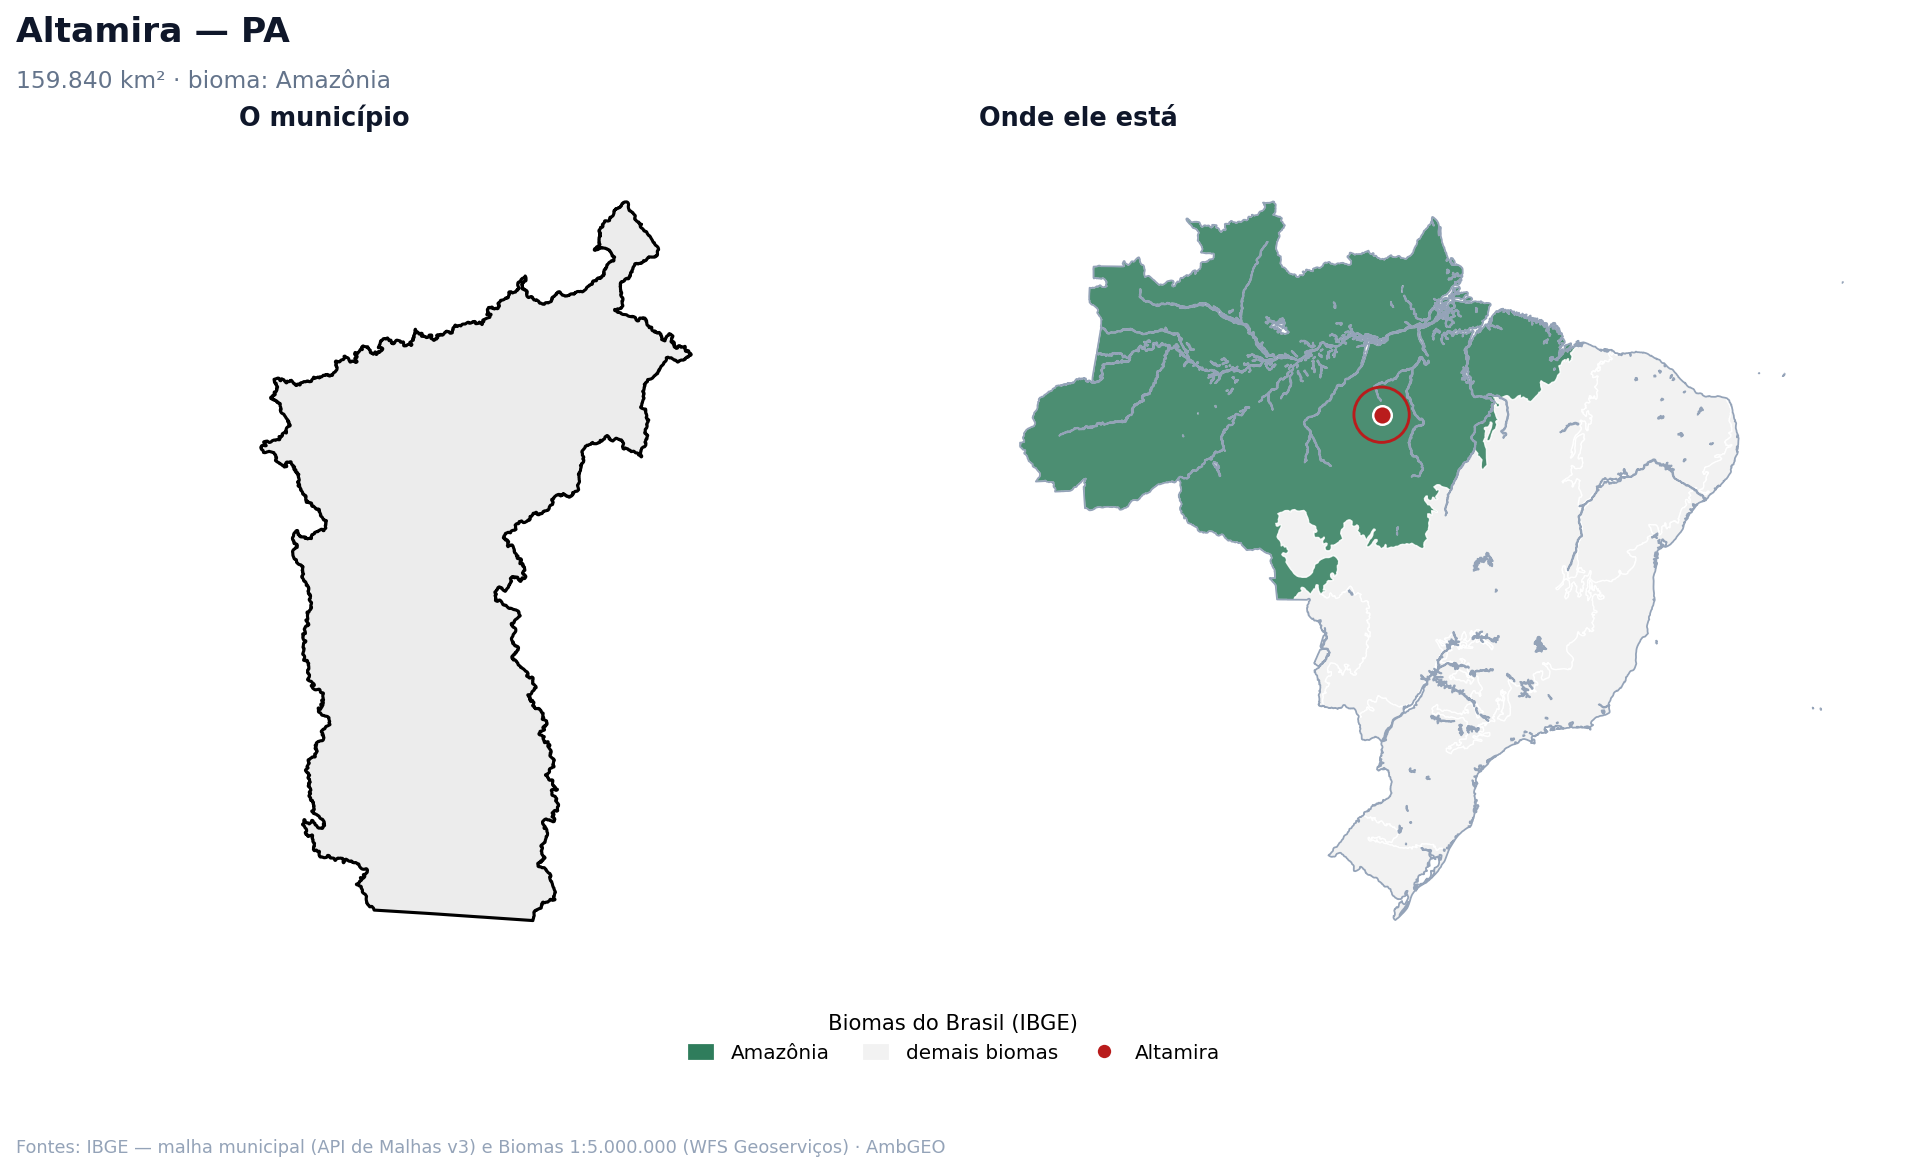

In [8]:
CRS_BRASIL = 5880        # SIRGAS 2000 / Policônica do Brasil — para o mapa do país

biomas_br = baixar_biomas_brasil()
biomas_proj = biomas_br.to_crs(CRS_BRASIL)
mun_brasil = municipio.to_crs(CRS_BRASIL)

destaque = [b for b in BIOMAS_MUN if b in set(biomas_br["chave"])]
paleta_bioma = {
    "amazonia": "#2f7d5c", "cerrado": "#c58a2e", "caatinga": "#b4693c",
    "mata_atlantica": "#3b7a9e", "pampa": "#7a8b3f", "pantanal": "#6b6ba8",
}
rotulo_bioma = dict(zip(biomas_br["chave"], biomas_br["nom_bioma"]))

fig, (ax_mun, ax_br), ax_leg = figura(
    titulo=f"{NOME_MUN} — {UF}",
    subtitulo=f"{br(AREA_MUN_KM2, 0)} km² · "
              f"bioma{'s' if len(destaque) > 1 else ''}: "
              f"{', '.join(rotulo_bioma[b] for b in destaque)}",
    nota="Fontes: IBGE — malha municipal (API de Malhas v3) e Biomas 1:5.000.000 "
         "(WFS Geoserviços) · AmbGEO",
    n_paineis=2, largura=12.6, altura=7.4)

# ---------- painel 1: o município ----------
mun_local = municipio.to_crs(CRS_METRICO)
mun_local.plot(ax=ax_mun, facecolor="#ececec", edgecolor="black", linewidth=1.4)
ax_mun.set_title("O município", fontsize=11.5, fontweight="bold",
                 color="#0f172a", loc="left", pad=8)
ax_mun.set_axis_off()

# ---------- painel 2: onde ele está ----------
biomas_proj.plot(ax=ax_br, facecolor="#f2f2f2", edgecolor="white", linewidth=0.6)
for chave in destaque:
    biomas_proj[biomas_proj["chave"] == chave].plot(
        ax=ax_br, facecolor=paleta_bioma.get(chave, "#9aa5b1"),
        edgecolor="white", linewidth=0.6, alpha=0.85)
biomas_proj.dissolve().boundary.plot(ax=ax_br, color="#94a3b8", linewidth=0.8)

ponto = mun_brasil.geometry.union_all().representative_point()
ax_br.scatter([ponto.x], [ponto.y], s=620, facecolor="none",
              edgecolor="#b91c1c", linewidth=1.3, zorder=5)
ax_br.scatter([ponto.x], [ponto.y], s=70, facecolor="#b91c1c",
              edgecolor="white", linewidth=1.1, zorder=6)

ax_br.set_title("Onde ele está", fontsize=11.5, fontweight="bold",
                color="#0f172a", loc="left", pad=8)
ax_br.set_axis_off()
ax_br.set_aspect("equal")

# ---------- legenda, na faixa reservada ----------
itens = [Patch(facecolor=paleta_bioma.get(b, "#9aa5b1"), edgecolor="white",
               label=rotulo_bioma[b]) for b in destaque]
itens.append(Patch(facecolor="#f2f2f2", edgecolor="white", label="demais biomas"))
itens.append(Line2D([], [], marker="o", linestyle="none", markersize=7,
                    markerfacecolor="#b91c1c", markeredgecolor="white",
                    label=f"{NOME_MUN}"))
por_legenda(ax_leg, itens, titulo="Biomas do Brasil (IBGE)")

arq = f"{SAIDA}_localizacao_{COD_MUN}.png"
fig.savefig(arq, dpi=200, bbox_inches="tight", facecolor="white")
print("Mapa de localização salvo em:", arq)
plt.show()


## 6. Extração dos dados do PRODES

O filtro espacial é enviado ao servidor no parâmetro `cql_filter`, combinando a caixa envolvente
do município com o recorte temporal:

```
BBOX(geom, minx, miny, maxx, maxy, 'EPSG:4674') AND year >= 2020
```

O servidor do INPE processa esse filtro e transmite apenas os polígonos correspondentes. É essa
delegação que torna a análise viável: em vez do conjunto nacional, transitam alguns megabytes.

A etapa anterior já identificou qual variação de filtro cada conjunto aceita — os biomas têm
pequenas diferenças de esquema, como o nome do campo de geometria — e aqui o filtro validado é
reutilizado, agora requisitando as geometrias.

Quando o município abrange mais de um bioma, cada conjunto é consultado separadamente. Os
resultados recebem uma coluna `bioma` indicando a origem e são reunidos numa única camada; o
`concat` alinha os esquemas, preenchendo com valor nulo os campos ausentes em algum deles.

In [9]:
def baixar_prodes(camada, cql):
    """Baixa os polígonos PRODES que satisfazem o filtro já validado na sondagem."""
    workspace = camada.split(":")[0]
    r = requests.get(f"{TERRABRASILIS}/{workspace}/ows",
                     params={"service": "WFS", "version": "2.0.0", "request": "GetFeature",
                             "typeNames": camada, "outputFormat": "application/json",
                             "srsName": "EPSG:4674", "cql_filter": cql},
                     timeout=900)
    r.raise_for_status()
    dados = r.json()
    if not dados.get("features"):
        return None
    print(f"    {br(len(dados['features']), 0)} polígonos · {len(r.content) / 1e6:.1f} MB")
    return gpd.GeoDataFrame.from_features(dados["features"], crs="EPSG:4674")


partes = []
for bioma, (camada, cql) in encontrados.items():
    print(f"  {bioma} ({camada})")
    parte = baixar_prodes(camada, cql)
    if parte is None:
        print("    nada retornado; pulando")
        continue
    parte["bioma"] = bioma          # marca a origem antes de empilhar
    partes.append(parte)

# Biomas diferentes podem trazer colunas diferentes; o concat alinha e preenche o que faltar
prodes = gpd.GeoDataFrame(pd.concat(partes, ignore_index=True), crs="EPSG:4674")
BIOMAS_TXT = " + ".join(encontrados)

print(f"\nTotal: {br(len(prodes), 0)} polígonos de {len(partes)} bioma(s)")
print("Colunas recebidas:", list(prodes.columns))
prodes.head(3)

  amazonia (prodes-amazon-nb:yearly_deforestation_biome)
    41.846 polígonos · 62.4 MB

Total: 41.846 polígonos de 1 bioma(s)
Colunas recebidas: ['geometry', 'uuid', 'fid', 'state', 'path_row', 'main_class', 'class_name', 'def_cloud', 'julian_day', 'image_date', 'year', 'area_km', 'scene_id', 'publish_year', 'source', 'satellite', 'sensor', 'bioma']


,geometry,uuid,fid,state,path_row,main_class,class_name,def_cloud,julian_day,image_date,year,area_km,scene_id,publish_year,source,satellite,sensor,bioma
0,"MULTIPOLYGON (((-53.7011 -4.1461, -53.7012 -4....",591823e2-d37c-47a2-9519-396f2eb28afb,10039,PA,22663,DESMATAMENTO,d2021,NaN,219,2021-08-07,2021,0.228165,1049,2021-01-01,None,Landsat,OLI,amazonia
1,"MULTIPOLYGON (((-52.1902 -6.0335, -52.1885 -6....",a9450cf8-b29b-4dd0-84f9-ce855f887deb,16459,PA,024012,DESMATAMENTO,d2024,0.0,218,2024-08-05,2024,0.005755,2202,2024-01-01,Amazonia,Sentinel-2,MSI,amazonia
2,"MULTIPOLYGON (((-55.1784 -7.2421, -55.1785 -7....",e1edb114-052a-496a-b71b-6f4fd6a66fb5,10075,PA,021013,DESMATAMENTO,d2025,0.0,197,2025-07-16,2025,0.041464,3250,2025-01-01,Amazonia,Sentinel-2,MSI,amazonia


### 6.1 Padronização do ano

O ano de referência aparece de duas formas nas camadas do PRODES: numa coluna `year` numérica
ou codificado em `class_name`, no formato `d2021`. A função abaixo reconhece ambos os casos e
produz uma coluna `ano` uniforme, de modo que as etapas seguintes funcionem igualmente para
qualquer bioma.

Em seguida o recorte temporal definido na configuração é aplicado.

In [10]:
def extrair_ano(df):
    """Devolve uma série de anos (int), venha ela de `year` ou de `class_name`."""
    if "year" in df.columns and df["year"].notna().any():
        return pd.to_numeric(df["year"], errors="coerce")
    for col in ("class_name", "classname", "mainclass", "main_class"):
        if col in df.columns:
            return pd.to_numeric(df[col].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
    raise KeyError("Não encontrei o ano nesta camada. Colunas: " + ", ".join(df.columns))


prodes["ano"] = extrair_ano(prodes).astype("Int64")
prodes = prodes[prodes["ano"] >= ANO_INICIO]
if ANO_FIM:
    prodes = prodes[prodes["ano"] <= ANO_FIM]

print(f"{len(prodes)} polígonos entre {int(prodes['ano'].min())} e {int(prodes['ano'].max())} "
      f"(ainda na caixa envolvente, não no limite exato)")

41846 polígonos entre 2020 e 2025 (ainda na caixa envolvente, não no limite exato)


## 7. Validação geométrica e recorte

Dados vetoriais derivados de imagens de satélite podem conter geometrias que violam as regras
topológicas do padrão OGC: anéis que se autointersectam, vértices coincidentes, polígonos que
se tocam em um único ponto. Essas inconsistências não impedem a visualização, mas afetam
operações geométricas como interseção e recorte.

A célula seguinte trata essas geometrias antes do recorte, em três níveis de intervenção:

1. **`make_valid()`** — reconstrói as geometrias inválidas segundo as regras do padrão OGC,
   equivalente à ferramenta *Corrigir geometrias* do QGIS. Como a reconstrução pode gerar
   coleções mistas, o resultado é explodido e filtrado para manter apenas a componente
   poligonal;
2. **`set_precision()`** — arredonda as coordenadas para 1 cm, eliminando divergências de
   precisão de ponto flutuante entre vértices que deveriam coincidir;
3. **interseção individual** — processa polígono a polígono, preservando os resultados válidos
   e informando quantos foram descartados.

Cada nível só é acionado se o anterior não concluir, e o método efetivamente utilizado é
reportado na saída.

### 7.1 O recorte

A caixa envolvente usada na consulta é um retângulo e inclui áreas dos municípios vizinhos.
O `clip` do GeoPandas restringe os dados ao limite municipal exato, seccionando os polígonos
que cruzam a fronteira.

A operação é feita no CRS métrico definido na etapa 2, o que permite calcular as áreas
diretamente em km².

In [11]:
import shapely


def _validar(g):
    """Aplica make_valid e devolve só a parte poligonal do resultado."""
    col = g.geometry.name
    invalidas = ~g.geometry.is_valid
    n = int(invalidas.sum())
    if n:
        g.loc[invalidas, col] = g.loc[invalidas, col].make_valid()
    # make_valid pode devolver linhas ou coleções; ficamos só com os polígonos
    g = g.explode(index_parts=False)
    g = g[g.geom_type.isin(["Polygon", "MultiPolygon"])]
    g = g[g.geometry.notna() & ~g.geometry.is_empty]
    return g.reset_index(drop=True), n


def reparar(gdf, precisao=None):
    """Devolve só polígonos válidos e não vazios. `precisao` em metros arredonda as coordenadas."""
    g = gdf.copy()
    g = g[g.geometry.notna() & ~g.geometry.is_empty]

    g, n_invalidas = _validar(g)       # 1º: consertar (set_precision exige geometria válida)

    if precisao:                       # 2º: snap de coordenadas — mata o ruído de ponto flutuante
        snap = shapely.set_precision(g.geometry.to_numpy(), precisao)
        g = g.set_geometry(gpd.GeoSeries(snap, index=g.index, crs=g.crs))
        g, _ = _validar(g)             # o snap pode reintroduzir invalidez; conferimos de novo

    return g, n_invalidas


def recortar(gdf, mascara):
    """Recorta `gdf` pela `mascara`, com três planos de contingência."""
    # Plano 1 — conserta o que está inválido e recorta normalmente
    gdf_ok, n1 = reparar(gdf)
    mask_ok, n2 = reparar(mascara)
    if n1 or n2:
        print(f"  geometrias inválidas corrigidas: {n1} no PRODES, {n2} no limite municipal")
    try:
        return gpd.clip(gdf_ok, mask_ok), "clip direto"
    except Exception as e:
        print(f"  plano 1 falhou ({type(e).__name__}); tentando com arredondamento de coordenadas")

    # Plano 2 — arredonda para 1 cm e tenta de novo
    gdf_snap, _ = reparar(gdf, precisao=0.01)
    mask_snap, _ = reparar(mascara, precisao=0.01)
    try:
        return gpd.clip(gdf_snap, mask_snap), "clip após snap de 1 cm"
    except Exception as e:
        print(f"  plano 2 falhou ({type(e).__name__}); recortando polígono a polígono")

    # Plano 3 — um a um, pulando os irrecuperáveis
    alvo = mask_snap.geometry.union_all() if hasattr(mask_snap.geometry, "union_all") \
           else mask_snap.geometry.unary_union
    indices, geometrias, descartados = [], [], 0
    for idx, geom in gdf_snap.geometry.items():
        try:
            corte = geom.intersection(alvo)
            if not corte.is_empty:
                indices.append(idx)
                geometrias.append(corte)
        except Exception:
            descartados += 1
    if descartados:
        print(f"  {descartados} polígonos descartados por geometria irrecuperável")

    saida = gdf_snap.loc[indices].copy()
    saida = saida.set_geometry(gpd.GeoSeries(geometrias, index=indices, crs=gdf_snap.crs))
    return saida, "interseção individual"

In [12]:
prodes_m = prodes.to_crs(CRS_METRICO)

print("Recortando no limite municipal...")
prodes_mun, metodo = recortar(prodes_m, municipio_m)
prodes_mun = prodes_mun.explode(index_parts=False)
prodes_mun = prodes_mun[prodes_mun.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

prodes_mun["area_km2"] = prodes_mun.geometry.area / 1e6
area_total = prodes_mun["area_km2"].sum()

print(f"\nMétodo usado ........: {metodo}")
print(f"Dentro da caixa .....: {len(prodes_m)} polígonos")
print(f"Dentro do município .: {len(prodes_mun)} polígonos")
print(f"Área desmatada ......: {br(area_total)} km²")
print(f"Equivale a ..........: {br(100 * area_total / AREA_MUN_KM2, 2)}% "
      f"do território de {NOME_MUN}")

Recortando no limite municipal...
  geometrias inválidas corrigidas: 7290 no PRODES, 0 no limite municipal

Método usado ........: clip direto
Dentro da caixa .....: 41846 polígonos
Dentro do município .: 9943 polígonos
Área desmatada ......: 2.811,4 km²
Equivale a ..........: 1,76% do território de Altamira


### 7.2 Distribuição por bioma

Quando o município abrange mais de um bioma, esta tabela mostra como o desmatamento se reparte
entre eles — informação necessária para interpretar corretamente o total.

Um bioma que apareça com zero polígonos indica que a camada tinha feições dentro da caixa
envolvente mas nenhuma dentro do limite municipal, situação esperada quando o retângulo de
consulta alcança territórios vizinhos.

In [13]:
por_bioma = (prodes_mun.groupby("bioma")
             .agg(poligonos=("area_km2", "size"), area_km2=("area_km2", "sum"))
             .reindex(list(encontrados))
             .fillna(0)
             .astype({"poligonos": int})
             .reset_index())
por_bioma["pct"] = 100 * por_bioma["area_km2"] / por_bioma["area_km2"].sum()

vazios = por_bioma.loc[por_bioma["poligonos"] == 0, "bioma"].tolist()
if vazios:
    print("Biomas que tocaram só a caixa envolvente, não o município:", ", ".join(vazios))

por_bioma

,bioma,poligonos,area_km2,pct
0,amazonia,9943,2811.37468,100.0


In [14]:
# Tabela-resumo por ano: o dado que alimenta o mapa e o gráfico
resumo = (prodes_mun.groupby("ano")
          .agg(poligonos=("area_km2", "size"), area_km2=("area_km2", "sum"))
          .reset_index()
          .sort_values("ano"))
resumo

,ano,poligonos,area_km2
0,2020,1601,800.122246
1,2021,1514,767.344358
2,2022,1730,627.233587
3,2023,1236,318.660547
4,2024,1981,167.213009
5,2025,1881,130.800933


## 8. Mapa do desmatamento por ano

A representação segue três critérios:

- **Território em cinza claro, limite em preto.** O município contextualiza a informação sem
  competir com ela.
- **Matiz única, do claro ao escuro.** O ano é uma variável ordenada, e a variação de
  intensidade transmite essa ordem diretamente. Matizes distintas por ano sugeririam categorias
  independentes, o que não corresponde ao dado.
- **Legenda em faixa própria.** Posicionada abaixo do mapa, com a área do desmatamento de cada
  ano, mantendo a identificação legível sem sobrepor a representação.

Mapa salvo em: prodes_municipio_mapa_1500602.png


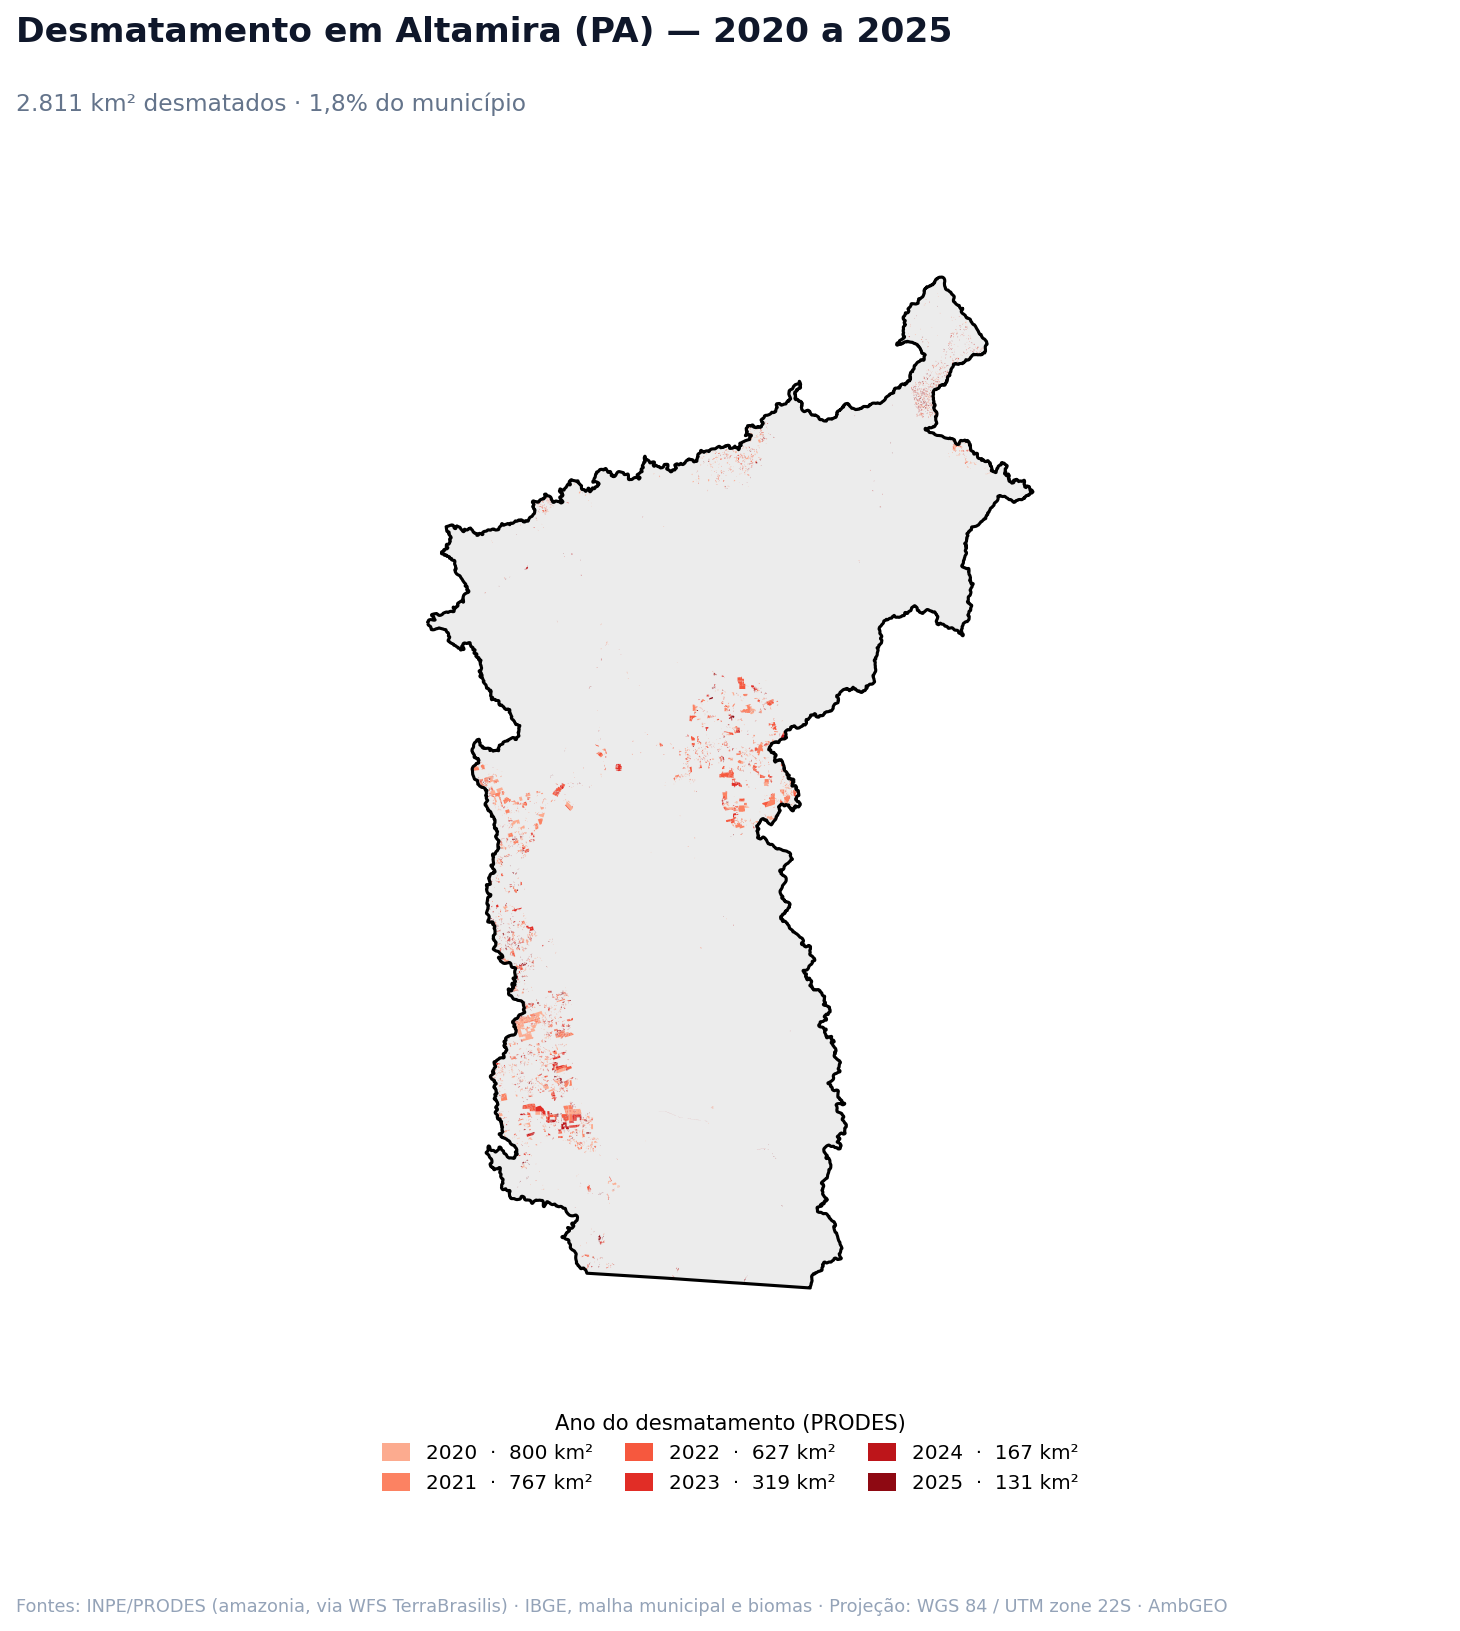

In [15]:
anos = sorted(resumo["ano"].dropna().astype(int).tolist())

# Ano é grandeza ordenada: uma única matiz, do claro (mais antigo) ao escuro (mais recente)
rampa = plt.get_cmap("Reds")
cores = {a: rampa(0.30 + 0.62 * i / max(len(anos) - 1, 1)) for i, a in enumerate(anos)}

itens = [Patch(facecolor=cores[a], edgecolor="none",
               label=f"{a}  ·  {br(resumo.loc[resumo['ano'] == a, 'area_km2'].iloc[0], 0)} km²")
         for a in anos]
COLUNAS = 3

fig, (ax,), ax_leg = figura(
    titulo=f"Desmatamento em {NOME_MUN} ({UF}) — {anos[0]} a {anos[-1]}",
    subtitulo=f"{br(area_total, 0)} km² desmatados · "
              f"{br(100 * area_total / AREA_MUN_KM2, 1)}% do município",
    nota=f"Fontes: INPE/PRODES ({BIOMAS_TXT}, via WFS TerraBrasilis) · IBGE, malha municipal "
         f"e biomas · Projeção: {CRS_METRICO.name} · AmbGEO",
    n_paineis=1, largura=9.6, altura=10.4,
    faixa_legenda=faixa_para(len(itens), COLUNAS))

# 1) o palco: o município em cinza claro
municipio_m.plot(ax=ax, facecolor="#ececec", edgecolor="none")
# 2) o dado: um desenho por ano, do mais antigo para o mais recente
for a in anos:
    prodes_mun[prodes_mun["ano"] == a].plot(ax=ax, facecolor=cores[a], edgecolor="none")
# 3) o limite por cima de tudo, para não ser encoberto
municipio_m.boundary.plot(ax=ax, color="black", linewidth=1.4)
ax.set_axis_off()

por_legenda(ax_leg, itens, titulo="Ano do desmatamento (PRODES)", colunas=COLUNAS)

arq = f"{SAIDA}_mapa_{COD_MUN}.png"
fig.savefig(arq, dpi=200, bbox_inches="tight", facecolor="white")
print("Mapa salvo em:", arq)
plt.show()


## 9. Evolução anual

O mapa mostra a distribuição espacial; o gráfico mostra o comportamento temporal, que é o que
permite identificar tendência.

São dois painéis lado a lado em vez de duas escalas num mesmo gráfico. Número de polígonos e
área desmatada são grandezas de naturezas diferentes, e representá-las sobre eixos distintos no
mesmo espaço distorce a comparação. Separadas, cada uma mantém a sua escala e a comparação se
faz pela forma das séries.

Os valores são rotulados diretamente sobre as barras, dispensando a leitura por eixo.

Gráfico salvo em: prodes_municipio_grafico_1500602.png


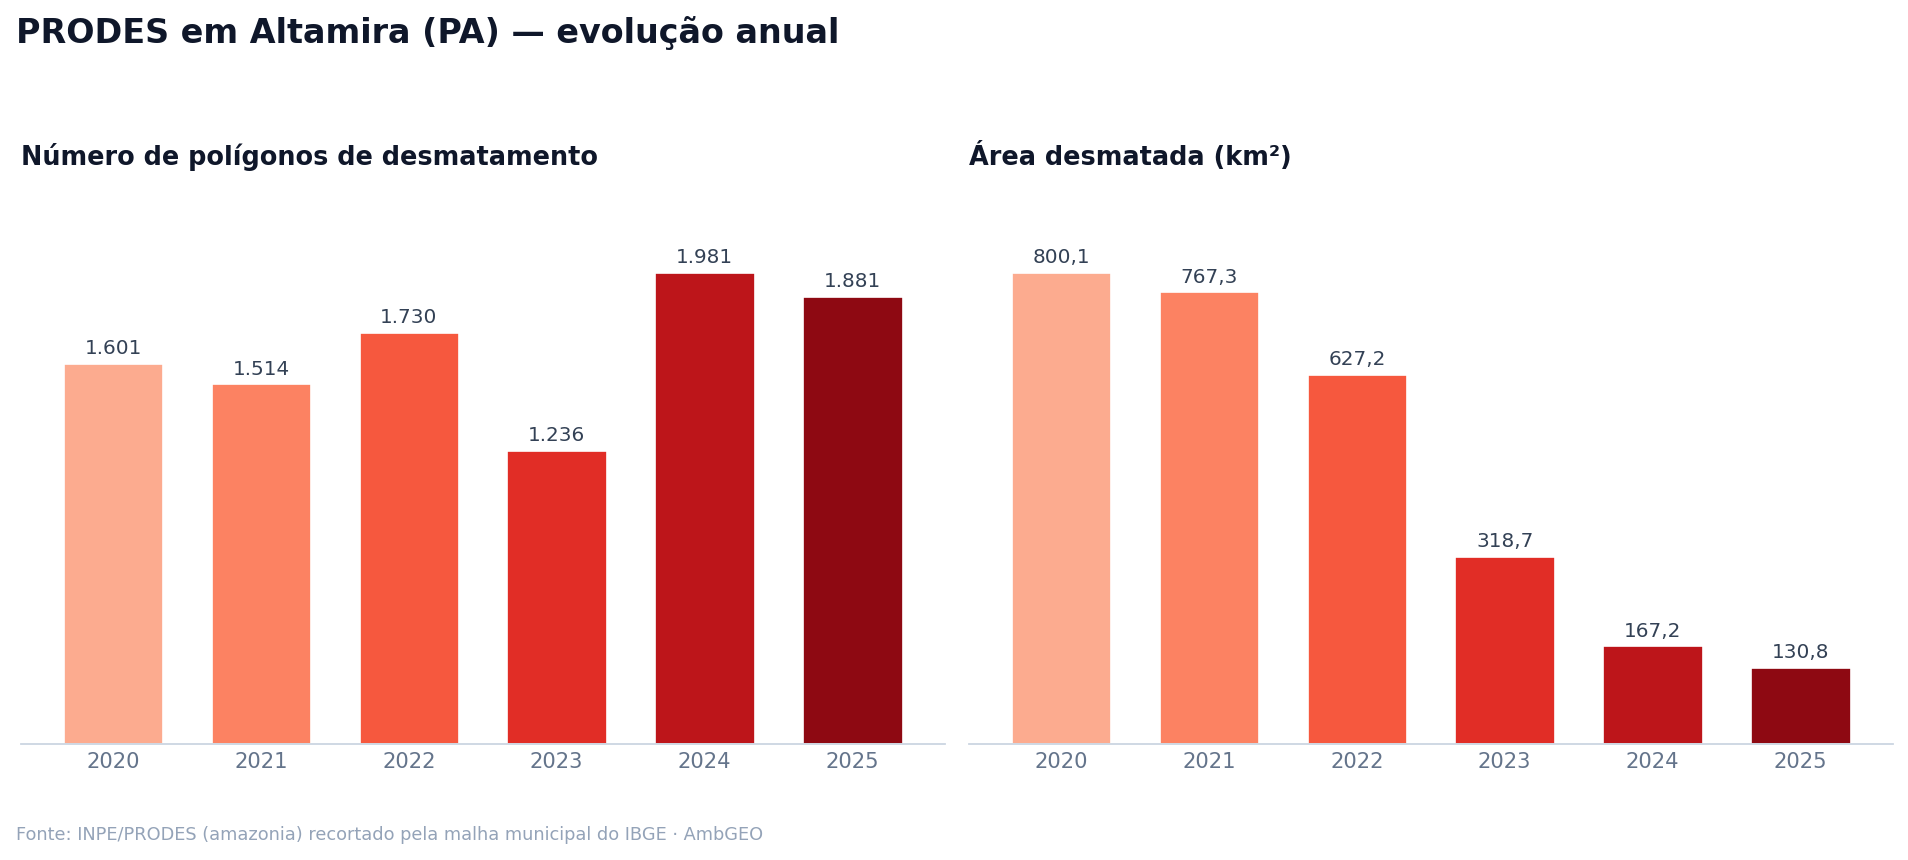

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), dpi=160)

paineis = [
    (axs[0], "poligonos", "Número de polígonos de desmatamento", 0),
    (axs[1], "area_km2",  "Área desmatada (km²)",                1),
]

for ax, coluna, titulo, casas in paineis:
    barras = ax.bar(resumo["ano"].astype(int).astype(str), resumo[coluna],
                    color=[cores[a] for a in resumo["ano"].astype(int)],
                    edgecolor="white", linewidth=1.2, width=0.68)

    # Rótulo direto em cima de cada barra: dispensa o leitor de mirar no eixo
    for barra, valor in zip(barras, resumo[coluna]):
        ax.annotate(br(valor, casas),
                    xy=(barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=9, color="#334155")

    ax.set_title(titulo, fontsize=11.5, fontweight="bold", color="#0f172a", loc="left", pad=10)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#cbd5e1")
    ax.tick_params(axis="both", length=0, colors="#64748b", labelsize=9.5)
    ax.set_yticks([])
    ax.margins(y=0.18)

fig.suptitle(f"PRODES em {NOME_MUN} ({UF}) — evolução anual",
             fontsize=15, fontweight="bold", color="#0f172a", x=0.01, ha="left", y=1.06)
fig.text(0.01, -0.06, f"Fonte: INPE/PRODES ({BIOMAS_TXT}) recortado pela malha municipal do IBGE · AmbGEO",
         fontsize=8, color="#94a3b8")

fig.tight_layout()
fig.savefig(f"{SAIDA}_grafico_{COD_MUN}.png", dpi=200, bbox_inches="tight", facecolor="white")
print("Gráfico salvo em:", f"{SAIDA}_grafico_{COD_MUN}.png")
plt.show()

## 10. Exportação dos resultados

O GeoPackage reúne as camadas produzidas e abre diretamente em QGIS, ArcGIS ou em outro
notebook; o CSV leva a tabela-resumo para planilha.

A função `limpar_para_gpkg()` prepara os dados para o formato:

- **remove a coluna `fid`.** No GeoPackage esse nome designa a chave primária da tabela. Os
  dados do WFS trazem um `fid` de origem que, após a divisão de polígonos no recorte, deixa de
  ser único. Descartando a coluna, o próprio formato numera as feições;
- **converte os tipos anuláveis do pandas** (`Int64`, `Float64`, `boolean`) para tipos que o
  driver OGR escreve nativamente;
- **serializa campos estruturados** eventualmente herdados do GeoJSON.

In [17]:
def limpar_para_gpkg(gdf):
    """Prepara um GeoDataFrame para virar camada de GeoPackage sem conflito de chave."""
    g = gdf.reset_index(drop=True).copy()

    # 'fid' é a chave primária do GeoPackage: se vier repetida do WFS, o insert falha
    g = g.drop(columns=[c for c in g.columns if c.lower() == "fid"], errors="ignore")

    for col in g.columns:
        if col == g.geometry.name:
            continue
        if g[col].map(lambda v: isinstance(v, (dict, list, set, tuple))).any():
            g[col] = g[col].astype(str)                  # OGR não escreve objeto aninhado
        elif str(g[col].dtype) in ("Int64", "Float64", "boolean"):
            g[col] = g[col].astype("float64") if g[col].isna().any() else g[col].astype("int64")

    return g


gpkg = f"{SAIDA}_{COD_MUN}.gpkg"
limpar_para_gpkg(municipio).to_file(gpkg, layer="limite_municipio", driver="GPKG")
limpar_para_gpkg(prodes_mun.to_crs("EPSG:4674")).to_file(gpkg, layer="prodes_recortado",
                                                         driver="GPKG")

csv = f"{SAIDA}_resumo_{COD_MUN}.csv"
resumo.to_csv(csv, index=False, encoding="utf-8-sig")

print("GeoPackage:", gpkg, "->", gpd.list_layers(gpkg)["name"].tolist())
print("Resumo CSV:", csv)

GeoPackage: prodes_municipio_1500602.gpkg -> ['limite_municipio', 'prodes_recortado']
Resumo CSV: prodes_municipio_resumo_1500602.csv


## 11. Auditoria de sobreposição

O PRODES é construído como **máscara incremental**: uma área identificada como desmatada em
determinado ano é retirada da floresta remanescente e não volta a ser mapeada nos anos
seguintes. Sob essa premissa, a soma das áreas anuais corresponde à área geográfica desmatada.

Na prática, alguns fatores podem introduzir sobreposições: as cenas Landsat se sobrepõem nas
bordas — o campo `path_row` registra a cena de origem de cada polígono —, a vetorização de anos
distintos nem sempre fecha exatamente nos mesmos vértices, e o recorte municipal divide
polígonos. O efeito é que determinadas áreas podem ser contabilizadas mais de uma vez.

Esta etapa mede esse efeito. O procedimento é geral e se aplica a qualquer camada vetorial:

1. **Identificação dos pares.** Um índice espacial seleciona os polígonos que se intersectam;
   permanecem apenas aqueles cuja interseção tem área efetiva, descartando contatos de borda.
2. **Decomposição em faces.** Os limites de todos os polígonos envolvidos são reunidos numa
   malha de linhas e repoligonizados. O resultado é um conjunto de faces que não se sobrepõem
   entre si, de modo que cada face admite uma única resposta para quantos polígonos a cobrem.
3. **Contagem.** Um ponto interior de cada face é consultado contra o índice espacial,
   retornando o número de polígonos originais que o contêm.

A saída é uma distribuição de área por frequência de mapeamento: quantos hectares foram
registrados uma vez, duas vezes, três vezes, e assim por diante.

In [18]:
import numpy as np
import shapely


def pares_sobrepostos(gdf, area_min_m2=1.0):
    """Pares (i, j) de polígonos cuja interseção tem área relevante."""
    i, j = gdf.sindex.query(gdf.geometry, predicate="intersects")
    dedup = i < j                                   # cada par contado uma vez só
    i, j = i[dedup], j[dedup]
    if len(i) == 0:
        return i, j, np.array([])
    inter = shapely.intersection(gdf.geometry.values[i], gdf.geometry.values[j])
    areas = shapely.area(inter)
    releva = areas > area_min_m2                    # descarta toque de borda (área zero)
    return i[releva], j[releva], areas[releva]


def faces_por_frequencia(gdf, indices):
    """Fatia a área dos polígonos indicados em faces e conta quantos cobrem cada uma."""
    sub = np.asarray(gdf.geometry.values[np.asarray(indices)])
    # 1) todas as bordas viram uma malha de linhas, já "nodada" nos cruzamentos
    malha = shapely.get_parts(shapely.unary_union(shapely.boundary(sub)))
    # 2) a malha é re-poligonizada em faces que não se sobrepõem entre si
    faces = shapely.get_parts(shapely.polygonize(malha))
    if len(faces) == 0:
        return gpd.GeoDataFrame({"n": []}, geometry=[], crs=gdf.crs)
    # 3) um ponto interno de cada face responde: quantos polígonos originais me cobrem?
    pontos = shapely.point_on_surface(faces)
    idx_ponto, _ = shapely.STRtree(sub).query(pontos, predicate="within")
    n = np.bincount(idx_ponto, minlength=len(faces))
    return gpd.GeoDataFrame({"n": n}, geometry=faces, crs=gdf.crs)


def auditar_sobreposicao(gdf, area_min_m2=1.0):
    """Devolve (tabela por frequência, faces sobrepostas, área da união em km²)."""
    i, j, _ = pares_sobrepostos(gdf, area_min_m2)
    area_uniao_km2 = float(shapely.area(shapely.unary_union(gdf.geometry.values)) / 1e6)

    if len(i) == 0:
        tabela = pd.DataFrame({"n": [1], "area_km2": [area_uniao_km2]})
        faces = gpd.GeoDataFrame({"n": []}, geometry=[], crs=gdf.crs)
    else:
        envolvidos = np.unique(np.concatenate([i, j]))
        faces = faces_por_frequencia(gdf, envolvidos)
        faces = faces[faces["n"] >= 2].copy()
        faces["area_km2"] = faces.geometry.area / 1e6
        tabela = faces.groupby("n")["area_km2"].sum().reset_index()
        # a área vista uma única vez é o resto da união
        area_1x = max(area_uniao_km2 - float(tabela["area_km2"].sum()), 0.0)
        tabela = pd.concat([pd.DataFrame({"n": [1], "area_km2": [area_1x]}), tabela],
                           ignore_index=True).sort_values("n")

    tabela = tabela[tabela["area_km2"] > 1e-9].copy()        # descarta classes vazias
    tabela["area_ha"] = tabela["area_km2"] * 100
    tabela["pct"] = 100 * tabela["area_km2"] / area_uniao_km2
    return tabela.reset_index(drop=True), faces, area_uniao_km2


In [19]:
TETO = 6      # a partir daqui as classes viram "6 ou mais" nos gráficos

tabela, faces, area_uniao_km2 = auditar_sobreposicao(prodes_mun, area_min_m2=1.0)
area_repetida = float(tabela.loc[tabela["n"] >= 2, "area_km2"].sum())

print(f"Soma das áreas dos polígonos : {br(prodes_mun['area_km2'].sum(), 2)} km²")
print(f"Área geográfica real (união) : {br(area_uniao_km2, 2)} km²")
print(f"Área contada mais de uma vez : {br(area_repetida, 3)} km²  "
      f"({br(area_repetida * 100)} ha · "
      f"{br(100 * area_repetida / area_uniao_km2, 3)}% do total)")

tabela_exibe = tabela.assign(
    area_km2=lambda d: d["area_km2"].round(4),
    area_ha=lambda d: d["area_ha"].round(2),
    pct=lambda d: d["pct"].round(4),
).rename(columns={"n": "vezes_mapeada"})
tabela_exibe


Soma das áreas dos polígonos : 2.811,37 km²
Área geográfica real (união) : 2.810,41 km²
Área contada mais de uma vez : 0,960 km²  (96,0 ha · 0,034% do total)


,vezes_mapeada,area_km2,area_ha,pct
0,1,2809.4545,280945.45,99.9658
1,2,0.9591,95.91,0.0341
2,3,0.0006,0.06,0.0000


### 11.1 Distribuição espacial das sobreposições

Quando existem, as sobreposições costumam ser pequenas na escala do município. A figura tem
por isso dois painéis: o da esquerda mostra a distribuição no território, e o da direita amplia
a maior ocorrência, com a janela dimensionada em função do alvo.

A rampa de cores vai do **amarelo ao laranja ao vermelho**, sequência quente que ordena as
classes da menor para a maior incidência. As classes mais altas são agrupadas em "6 ou mais"
para manter a legenda legível; a tabela da célula anterior preserva o detalhe completo.

Mapa salvo em: prodes_municipio_sobreposicao_1500602.png


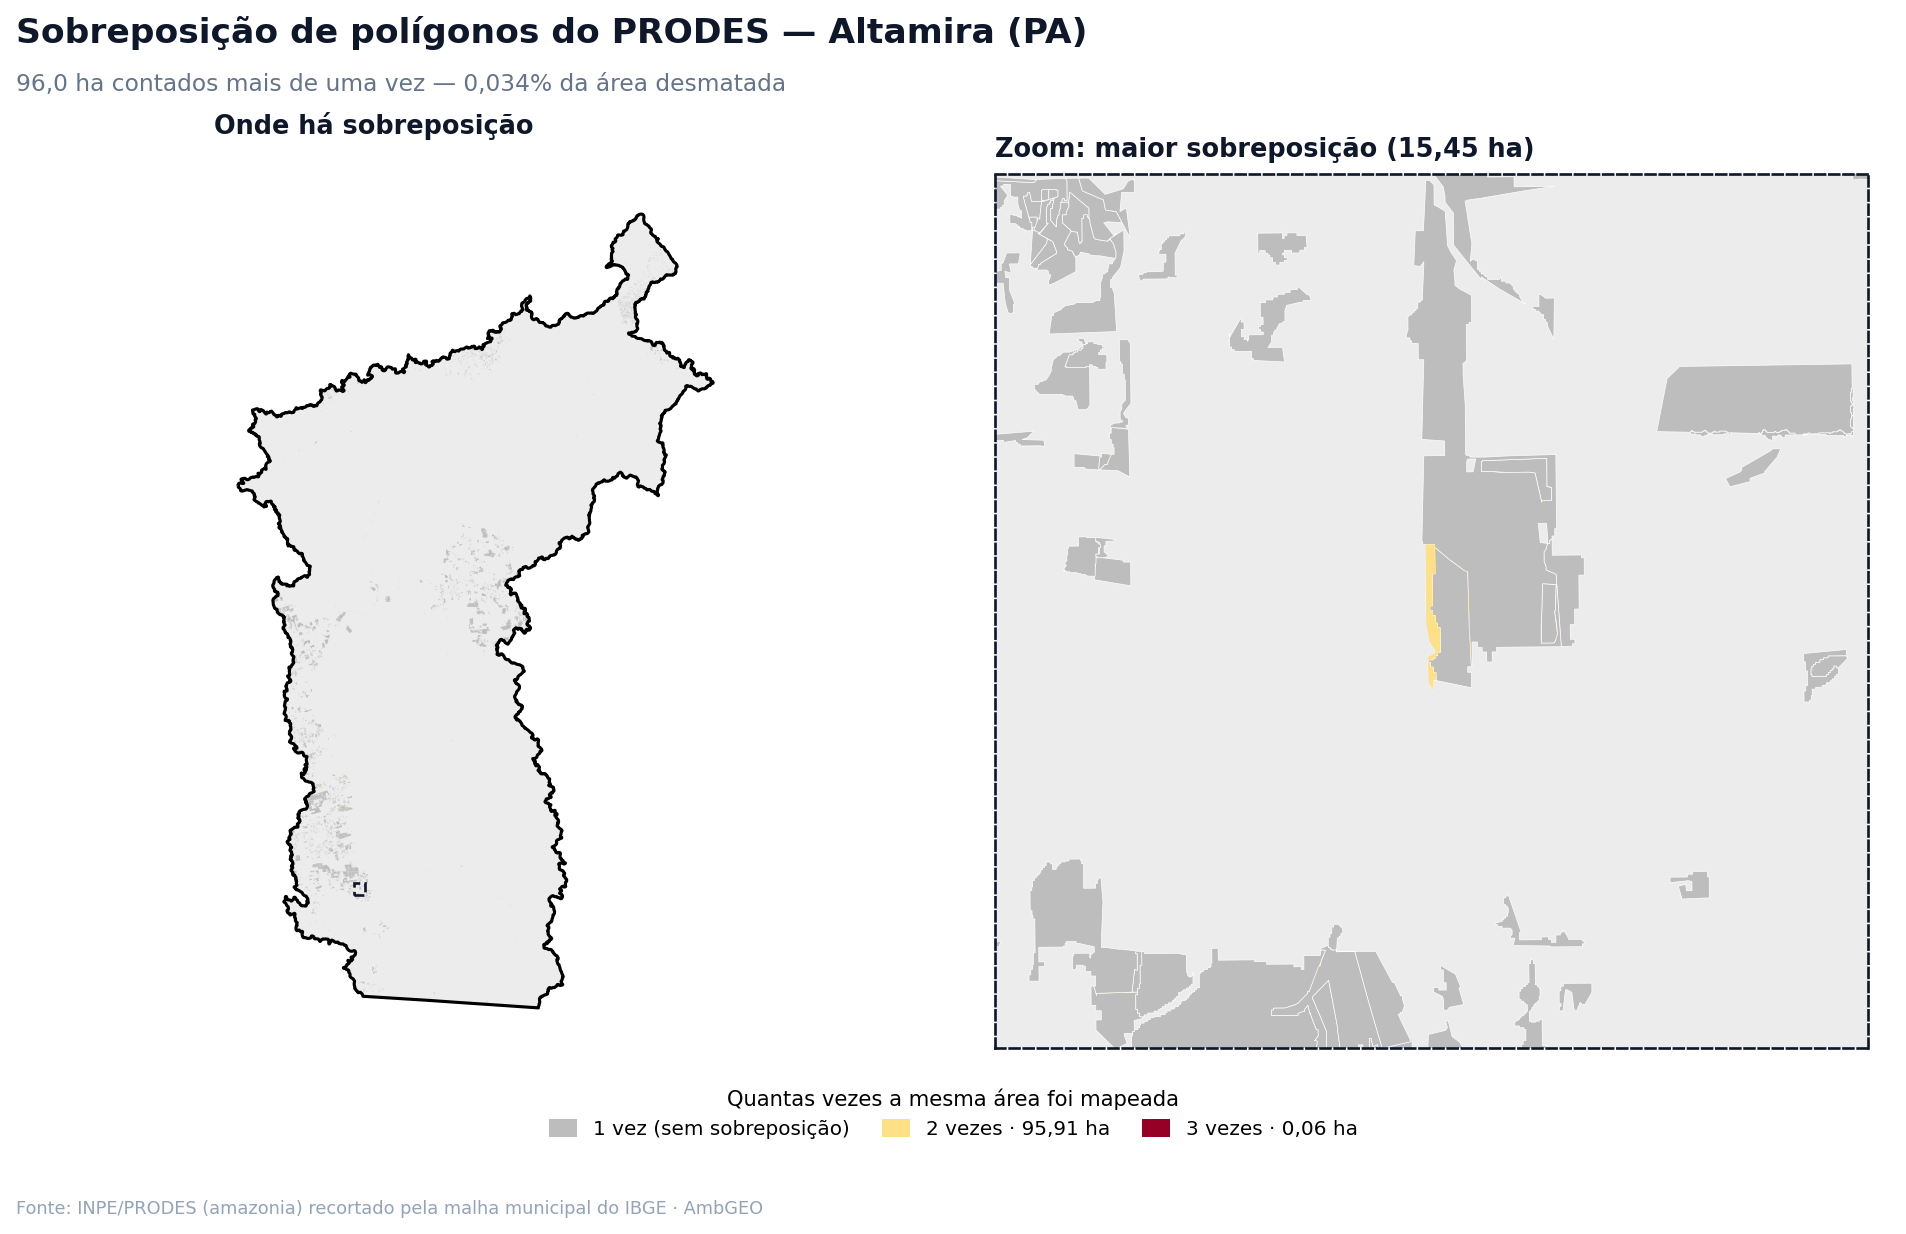

In [20]:
if faces.empty:
    print("Nenhuma sobreposição encontrada: o PRODES se comporta como máscara incremental.")
else:
    # Classes com teto: quinze níveis na legenda seriam ilegíveis
    faces["classe"] = faces["n"].clip(upper=TETO)
    niveis = sorted(faces["classe"].unique().tolist())
    rotulo = lambda k: (f"{k} ou mais vezes" if k == TETO and faces["n"].max() > TETO
                        else f"{k} vezes")

    # Amarelo -> laranja -> vermelho: rampa sequencial, quente, do menos ao mais grave
    rampa = plt.get_cmap("YlOrRd")
    cor_n = {k: rampa(0.20 + 0.75 * i / max(len(niveis) - 1, 1)) for i, k in enumerate(niveis)}

    # Janela de zoom proporcional à maior face sobreposta
    maior = faces.loc[faces["area_km2"].idxmax()]
    cx, cy = maior.geometry.centroid.x, maior.geometry.centroid.y
    x0, y0, x1, y1 = maior.geometry.bounds
    JANELA = max(2000.0, 3 * max(x1 - x0, y1 - y0))   # metros

    itens = [Patch(facecolor="#bdbdbd", edgecolor="none", label="1 vez (sem sobreposição)")]
    itens += [Patch(facecolor=cor_n[k], edgecolor="none",
                    label=f"{rotulo(k)} · "
                          f"{br(faces.loc[faces['classe'] == k, 'area_km2'].sum() * 100, 2)} ha")
              for k in niveis]
    COLUNAS = 3

    fig, (ax_todo, ax_zoom), ax_leg = figura(
        titulo=f"Sobreposição de polígonos do PRODES — {NOME_MUN} ({UF})",
        subtitulo=f"{br(area_repetida * 100)} ha contados mais de uma vez — "
                  f"{br(100 * area_repetida / area_uniao_km2, 3)}% da área desmatada",
        nota=f"Fonte: INPE/PRODES ({BIOMAS_TXT}) recortado pela malha municipal do IBGE · AmbGEO",
        n_paineis=2, largura=12.6, altura=7.8,
        faixa_legenda=faixa_para(len(itens), COLUNAS))

    # --- painel A: o município inteiro ---
    municipio_m.plot(ax=ax_todo, facecolor="#ececec", edgecolor="none")
    prodes_mun.plot(ax=ax_todo, facecolor="#bdbdbd", edgecolor="none")
    for k in niveis:
        faces[faces["classe"] == k].plot(ax=ax_todo, facecolor=cor_n[k], edgecolor="none")
    municipio_m.boundary.plot(ax=ax_todo, color="black", linewidth=1.4)
    ax_todo.add_patch(Rectangle((cx - JANELA, cy - JANELA), 2 * JANELA, 2 * JANELA,
                                fill=False, edgecolor="#0f172a", linewidth=1.2, linestyle="--"))
    ax_todo.set_title("Onde há sobreposição", fontsize=11.5, fontweight="bold",
                      color="#0f172a", loc="left", pad=8)
    ax_todo.set_axis_off()

    # --- painel B: zoom no maior conflito ---
    municipio_m.plot(ax=ax_zoom, facecolor="#ececec", edgecolor="none")
    prodes_mun.plot(ax=ax_zoom, facecolor="#bdbdbd", edgecolor="white", linewidth=0.3)
    for k in niveis:
        faces[faces["classe"] == k].plot(ax=ax_zoom, facecolor=cor_n[k], edgecolor="none")
    ax_zoom.set_xlim(cx - JANELA, cx + JANELA)
    ax_zoom.set_ylim(cy - JANELA, cy + JANELA)
    ax_zoom.set_title(f"Zoom: maior sobreposição ({br(maior['area_km2'] * 100, 2)} ha)",
                      fontsize=11.5, fontweight="bold", color="#0f172a", loc="left", pad=8)
    for lado in ax_zoom.spines.values():
        lado.set_color("#0f172a"); lado.set_linewidth(1.2); lado.set_linestyle("--")
    ax_zoom.set_xticks([]); ax_zoom.set_yticks([])

    por_legenda(ax_leg, itens, titulo="Quantas vezes a mesma área foi mapeada", colunas=COLUNAS)

    arq = f"{SAIDA}_sobreposicao_{COD_MUN}.png"
    fig.savefig(arq, dpi=200, bbox_inches="tight", facecolor="white")
    print("Mapa salvo em:", arq)
    plt.show()


### 11.2 Quantificação por classe

O gráfico apresenta a área de cada classe de frequência em hectares e em proporção do total.

A classe `1x` corresponde à área registrada uma única vez, o comportamento esperado da máscara
incremental. As demais classes representam área contabilizada em duplicidade.

A leitura é direta: se `1x` concentra praticamente todo o total, a soma das áreas anuais pode
ser usada como estimativa da área desmatada. Se as classes superiores têm peso relevante, esse
somatório superestima o valor real, e a tabela indica em quantos hectares.

A escala vertical é logarítmica, sem a qual as classes menos frequentes ficariam indistinguíveis.

Gráfico salvo em: prodes_municipio_frequencia_1500602.png


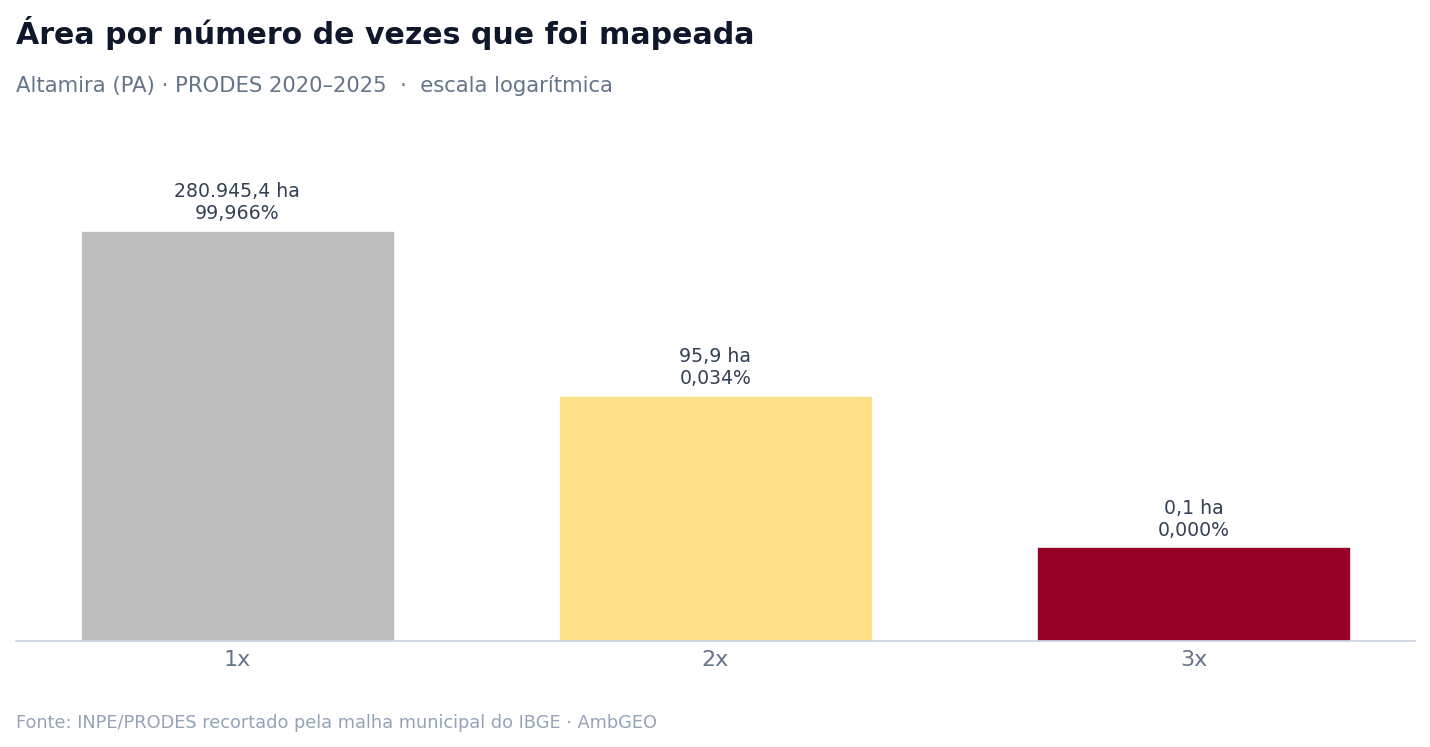

In [21]:
# Agrupa as classes altas para o gráfico ficar legível (a tabela acima guarda o detalhe)
barras_df = (tabela.assign(classe=lambda d: d["n"].clip(upper=TETO))
             .groupby("classe", as_index=False)[["area_km2", "area_ha", "pct"]].sum())

rampa = plt.get_cmap("YlOrRd")          # amarelo -> laranja -> vermelho
classes = barras_df["classe"].astype(int).tolist()
sobrep = [k for k in classes if k >= 2]
cor_n = {k: rampa(0.20 + 0.75 * i / max(len(sobrep) - 1, 1)) for i, k in enumerate(sobrep)}
cores_barra = ["#bdbdbd" if k == 1 else cor_n[k] for k in classes]
nomes = [("1x" if k == 1 else (f"{k}x+" if k == TETO and tabela["n"].max() > TETO else f"{k}x"))
         for k in classes]

fig = plt.figure(figsize=(9.4, 4.8), dpi=160)
ax = fig.add_axes([0.04, 0.14, 0.93, 0.66])      # posição fixa: título e nota têm lugar próprio

barras = ax.bar(nomes, barras_df["area_ha"], color=cores_barra,
                edgecolor="white", linewidth=1.2, width=0.66)
for b, ha_, pct in zip(barras, barras_df["area_ha"], barras_df["pct"]):
    ax.annotate(f"{br(ha_)} ha\n{br(pct, 3)}%",
                xy=(b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=8.5, color="#334155")

if len(classes) > 1 and barras_df["area_ha"].min() > 0:
    ax.set_yscale("log")                # sem log, as classes raras somem

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#cbd5e1")
ax.tick_params(axis="x", length=0, colors="#64748b", labelsize=10)
ax.tick_params(axis="y", which="both", length=0, labelleft=False)
ax.margins(y=0.30)

fig.text(0.04, 0.955, "Área por número de vezes que foi mapeada",
         fontsize=13.5, fontweight="bold", color="#0f172a", va="top")
fig.text(0.04, 0.878, f"{NOME_MUN} ({UF}) · PRODES {anos[0]}–{anos[-1]}"
         + ("  ·  escala logarítmica" if ax.get_yscale() == "log" else ""),
         fontsize=9.5, color="#64748b", va="top")
fig.text(0.04, 0.035, "Fonte: INPE/PRODES recortado pela malha municipal do IBGE · AmbGEO",
         fontsize=8, color="#94a3b8", va="center")

arq = f"{SAIDA}_frequencia_{COD_MUN}.png"
fig.savefig(arq, dpi=200, bbox_inches="tight", facecolor="white")
print("Gráfico salvo em:", arq)
plt.show()


### 11.3 Exportação da auditoria

As faces sobrepostas são gravadas como camada do GeoPackage e a distribuição por frequência
como CSV.

Sobreposta aos polígonos originais em um SIG, a camada permite inspecionar caso a caso quais
feições estão envolvidas — útil para documentar a metodologia ou justificar os valores
apresentados.

In [22]:
csv_freq = f"{SAIDA}_sobreposicao_{COD_MUN}.csv"
tabela.rename(columns={"n": "vezes_mapeada"}).to_csv(csv_freq, index=False, encoding="utf-8-sig")
print("Tabela de frequência:", csv_freq)

if not faces.empty:
    limpar_para_gpkg(faces.to_crs("EPSG:4674")).to_file(
        f"{SAIDA}_{COD_MUN}.gpkg", layer="sobreposicoes", driver="GPKG")
    print("Camada 'sobreposicoes' adicionada ao GeoPackage")


Tabela de frequência: prodes_municipio_sobreposicao_1500602.csv
Camada 'sobreposicoes' adicionada ao GeoPackage


---

## Síntese do fluxo

O notebook percorreu o caminho completo entre a pergunta e o resultado publicável:

1. identificou o município no cadastro oficial do IBGE;
2. obteve o limite territorial vigente por API, em GeoJSON;
3. determinou os biomas de abrangência cruzando esse limite com a cartografia oficial de biomas,
   com o processamento executado no servidor;
4. situou a análise com um mapa de localização;
5. extraiu do PRODES apenas os polígonos da área de interesse, em cada bioma necessário;
6. validou as geometrias, recortou no limite municipal e calculou áreas em sistema projetado;
7. produziu o mapa de distribuição espacial por ano;
8. produziu o gráfico de evolução anual;
9. exportou geometrias e tabelas em formatos reutilizáveis;
10. auditou a consistência do dado, quantificando eventual dupla contagem.

Todas as informações vieram de fontes públicas e oficiais, e cada etapa está registrada no
código — o que torna o resultado verificável e reprodutível por terceiros.

**A automação se refaz sozinha.** Alterando os parâmetros da célula de configuração, o mesmo
notebook responde à mesma pergunta para qualquer município brasileiro. A cada atualização do
PRODES, basta executá-lo novamente.

## Observações metodológicas

- **Ano PRODES.** O calendário do PRODES vai de agosto a julho, e o ano mais recente da série
  pode estar em versão preliminar. A coluna `publish_year`, presente nos dados, permite
  verificar a edição de publicação de cada polígono.
- **Cálculo de área.** As áreas são calculadas na zona UTM correspondente ao município. Para
  municípios de grande extensão longitudinal, uma projeção equivalente de abrangência regional
  pode ser mais adequada.
- **Escala das camadas.** O cruzamento com biomas usa a base em 1:250.000; o mapa de localização
  usa a de 1:5.000.000, apropriada à representação nacional.

## Possíveis extensões

- **Análise comparativa.** Percorrer uma lista de municípios e consolidar os resultados num
  painel único.
- **Série histórica ampliada.** Definir `ANO_INICIO = 2008` para acompanhar duas décadas.
- **Outras camadas do mesmo serviço.** `listar_camadas(WORKSPACES["amazonia"])` lista o que mais
  o TerraBrasilis publica no conjunto, incluindo hidrografia, floresta remanescente e máscaras
  auxiliares.
- **Outros recortes territoriais.** Substituir a malha municipal por terras indígenas, unidades
  de conservação ou assentamentos, mantendo o restante do fluxo.
- **Execução periódica.** Agendar a execução para acompanhar as atualizações da base.

---

*AmbGEO — geotecnologia aplicada.*